In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

# DATASET

In [3]:
# dataset reels
reels = pd.read_csv("/kaggle/input/datasets/filippotenani/data-markov/reels_engineered.csv")

# dataset storie
stories = pd.read_csv("/kaggle/input/datasets/filippotenani/data-markov/stories_engineered.csv")

# MARKOV CHAIN

We want to model a Markov Chain to see if successful posts bring "fame" to a creator making their subsequent posts more successful too.

We consider a single creator (generally the one with the most posts so we have more data for the Markov Chain) and sort their posts in chronological order. Then we define a success metric for the post, which measures whether a post by that creator is successful or not, for example Reach: if a post reaches many people then it is successful, while if it reaches few it is not. We will tend to use absolute metrics and not relative ones (so Reach and not Engagement Rate) because we are evaluating the posts of a single creator so we don't need to divide by Reach to make it comparable to other creators.

We define two states in the Markov Chain:
- State 0: a post is in state 0 if its success (e.g. Reach) is below the average of the chosen creator (e.g. below the average Reach of the chosen creator)
- State 1: a post is in state 1 if its success is above the average of the chosen creator

What we want to compute is the Transition Matrix, i.e. the probabilities of going from state 0 to state 1, from state 0 to state 0, from state 1 to state 0, from state 1 to state 1: that is, if a post by that creator is successful (state 1), we expect that due to a sort of "fame effect" the next post in chronological order by that creator has a higher probability of also being successful (state 1) and a lower probability of being unsuccessful (state 0).

## MARKOV CHAIN (REELS)

In [43]:
reels["Creator name"].value_counts().sum()

np.int64(1013)

In [ ]:
reels.columns

In [ ]:
# DEFINIRE POST CON STATO 0-1

# we choose the creator to run the markov chain on, the one with the most posts so we have more data
CREATOR = "BENNET"

# filtriamo post del creator scelto e li ordiniamo in ordine cronologico usando data e ora
data = (
    reels[reels["Creator name"] == CREATOR]
    .copy()
    .assign(datetime=lambda df: pd.to_datetime(
        df["Post creation date"].astype(str) + " " + df["Post creation time"].astype(str)
    ))
    .sort_values("datetime")
    .reset_index(drop=True)
)

# usiamo la Reach come indicatore del successo del post (di successo se raggiunge molte persone)
# we compute the average Reach of the chosen creator then define the state of each post:
# se la Reach di quel post è sotto la media: stato = 0
# se la Reach di quel post è sopra la media: stato = 1
creator_mean = data["Reach"].mean()
data["state"] = (data["Reach"] >= creator_mean).astype(int)  # 0=sotto, 1=sopra

In [ ]:
# CONTARE LE TRANSIZIONI

# we associate each state (except the last) with the next state (so excluding the first)
transitions = list(zip(data["state"][:-1], data["state"][1:]))

# contiamo il numero di transizioni presenti nella serie storica dei post di quel creator
# ovvero contiamo tutte le transizioni 1>1, 1>0, 0>1, 0>0
counts = np.zeros((2, 2), dtype=int)
for s_from, s_to in transitions:
    counts[s_from][s_to] += 1

print(pd.DataFrame(counts, index=["from 0 (low)", "from 1 (high)"],
                           columns=["to 0 (low)", "to 1 (high)"]))

In [ ]:
# TRANSITION MATRIX

# normalizza per riga la matrice dei conteggi delle transizioni (ogni riga somma a 1)
# cosi otteniamo la matrice delle probabilita (Matrice di Transizione)
row_sums = counts.sum(axis=1, keepdims=True)
trans_matrix = counts / row_sums

# stampiamo la matrice
tm = pd.DataFrame(
    trans_matrix,
    index=["from 0 (low)", "from 1 (high)"],
    columns=["to 0 (low)", "to 1 (high)"]
)

print("\nTransition Matrix:")
print(tm.round(3))

In [ ]:
# transition matrix del top 1 creator per i reels

BENNET
               to 0 (low)  to 1 (high)
from 0 (low)        0.710        0.290
from 1 (high)       0.417        0.583

### INSIGHTS

A poor reel has a 71% probability of being followed by another poor reel, a successful one has a 58% probability of being followed by another successful one.

A creator tends to remain trapped in a negative moment more than they manage to maintain a hot streak.

From a social media management perspective, synchronizing collaborations with hot periods maximizes reach, while intervening with an external stimulus during cold periods is fundamental to break the negative cycle.

## MARKOV CHAIN (STORIES)

In [ ]:
stories["Creator name"].value_counts()

In [ ]:
stories.columns

In [ ]:
# scegliamo il creator su cui fare la markov chain
# since for stories we have more creators with a significant series of content,
# we don't consider only the top 1 creator but the top 5, also to see if they behave similarly
top_five = ["la casa di mattia", "Vittorio Pettinato", "Valeria Angione",
            "ThePozzolisFamily", "Claudio Valletta"]
i = 0  # scegli creator 0,1,2,3,4

CREATOR = top_five[i]

In [ ]:
# DEFINIRE POST CON STATO 0-1

# filtriamo post del creator scelto e li ordiniamo in ordine cronologico usando data e ora
data = (
    stories[stories["Creator name"] == CREATOR]
    .copy()
    .assign(datetime=lambda df: pd.to_datetime(
        df["Post creation date"].astype(str) + " " + df["Post creation time"].astype(str)
    ))
    .sort_values("datetime")
    .reset_index(drop=True)
)

# usiamo la Reach come indicatore del successo del post (di successo se raggiunge molte persone)
# we compute the average Reach of the chosen creator then define the state of each post:
# se la Reach di quel post è sotto la media: stato = 0
# se la Reach di quel post è sopra la media: stato = 1
creator_mean = data["Reach"].mean()
data["state"] = (data["Reach"] >= creator_mean).astype(int)  # 0=sotto, 1=sopra

In [ ]:
# CONTARE LE TRANSIZIONI

# we associate each state (except the last) with the next state (so excluding the first)
transitions = list(zip(data["state"][:-1], data["state"][1:]))

# contiamo il numero di transizioni presenti nella serie storica dei post di quel creator
# ovvero contiamo tutte le transizioni 1>1, 1>0, 0>1, 0>0
counts = np.zeros((2, 2), dtype=int)
for s_from, s_to in transitions:
    counts[s_from][s_to] += 1

print(pd.DataFrame(counts, index=["from 0 (low)", "from 1 (high)"],
                           columns=["to 0 (low)", "to 1 (high)"]))

In [ ]:
# TRANSITION MATRIX

# normalizza per riga la matrice dei conteggi delle transizioni (ogni riga somma a 1)
# cosi otteniamo la matrice delle probabilita (Matrice di Transizione)
row_sums = counts.sum(axis=1, keepdims=True)
trans_matrix = counts / row_sums

# stampiamo la matrice
tm = pd.DataFrame(
    trans_matrix,
    index=["from 0 (low)", "from 1 (high)"],
    columns=["to 0 (low)", "to 1 (high)"]
)

print("\nTransition Matrix:")
print(tm.round(3))

In [ ]:
# transition matrix dei top 5 creators per le storie

LA CASA DI MATTIA
               to 0 (low)  to 1 (high)
from 0 (low)        0.812        0.188
from 1 (high)       0.300        0.700


VITTORIO PETTINATO
               to 0 (low)  to 1 (high)
from 0 (low)        0.737        0.263
from 1 (high)       0.308        0.692


VALERIA ANGIONE
               to 0 (low)  to 1 (high)
from 0 (low)        0.733        0.267
from 1 (high)       0.286        0.714

THE POZZOLIS FAMILY
               to 0 (low)  to 1 (high)
from 0 (low)        0.857        0.143
from 1 (high)       0.273        0.727

CLAUDIO VALLETTA
               to 0 (low)  to 1 (high)
from 0 (low)        0.692        0.308
from 1 (high)       0.455        0.545

### INSIGHTS

The five creators show similar transition matrices: a low state has a 69-86% probability of staying low, a high state has a 55-73% probability of staying high, with cold periods generally more stable than hot ones.

Claudio Valletta is somewhat borderline, whose high state persists only in 54.5% of cases, the lowest value among all analyzed creators. For him hot periods are less stable compared to the others, which suggests that performance peaks are more episodic and harder to exploit as a prolonged window.

The overall similarity between different creators suggests that the pattern is largely a structural property, probably linked to the algorithm, rather than an individual trait.

The same principle suggested for reels applies: exploit hot periods for campaigns and actively intervene during cold ones to prevent them from prolonging, with the caveat that for some creators (like Claudio Valletta) the hot window must be seized promptly.

# MORAN INDEX

# MORAN INDEX

Based on the analyses done previously with Markov Chains, we also want to do a graphical/exploratory analysis regarding the success of a creator's posts.

In particular for this analysis we use the Moran Index: it is an index typically used in Spatial Statistics to see if there is spatial correlation between a point and its neighbors, specifically if a point has a high value of a variable X, we want to see if its neighbors also have a high value of that variable X or if instead the point is an outlier (e.g.: a rich house in a rich neighborhood, whereas if it were a poor house in a rich neighborhood it would be an outlier).

We want to apply the same principle but with posts: for each post (except the first and last ones) we take the K posts after and the K posts before in chronological order. If a post is popular, we think that often it is surrounded by other popular posts again due to what we called "fame effect", so if a post is popular we expect that more or less the K posts before and after are also somewhat popular because sometimes popularity is an isolated and fortuitous event, but often it is due to a "hot" period of that creator.

In [ ]:
# MORAN INDEX: FUNZIONE

# K=3: ogni post viene confrontato con i 3 precedenti e i 3 successivi
# scelto perche con serie di 30-50 post garantisce abbastanza vicini senza perdere troppi bordi
K = 3

def plot_moran(ax, reach_series, creator_name, K=K):
    # standardizziamo la reach di tutti i post del creator (z-score) cosi che la media sia in 0
    z = ((reach_series - reach_series.mean()) / reach_series.std()).values
    N = len(z)

    # calcoliamo il lag spaziale per ogni post i (esclusi i primi e ultimi K)
    # the lag and the mean of the z-scores of neighboring posts (K before and K after, excluding the post itself)
    indices = range(K, N - K)
    z_i   = np.array([z[i] for i in indices])
    z_lag = np.array([
        np.concatenate([z[i - K:i], z[i + 1:i + K + 1]]).mean()
        for i in indices
    ])

    # we compute Moran's I as the slope of the regression line in the Moran scatter plot
    moran_i, intercept = np.polyfit(z_i, z_lag, 1)

    # post alto vuol dire z_score sopra la media (sopra 0)
    # vicini alti vuol dire z_score medio dei vicini sopra 0
    # (z_score è reach standardizzata)
    # assegniamo ogni post al suo quadrante:
    # HH: post alto con vicini alti (periodo caldo)
    # LL: post basso con vicini bassi (periodo freddo)
    # HL: post alto con vicini bassi (outlier positivo)
    # LH: post basso con vicini alti (outlier negativo)
    quadrants = np.array([
        'HH' if zi >= 0 and li >= 0 else
        'LL' if zi <  0 and li <  0 else
        'HL' if zi >= 0 and li <  0 else
        'LH'
        for zi, li in zip(z_i, z_lag)
    ])

    # scatter plot colorato per quadrante
    quad_colors = {'HH': '#e63946', 'LL': '#457b9d', 'HL': '#f4a261', 'LH': '#2a9d8f'}
    for q, color in quad_colors.items():
        mask = quadrants == q
        ax.scatter(z_i[mask], z_lag[mask], color=color, alpha=0.75, s=55,
                   label=q, zorder=3, edgecolors='white', linewidths=0.5)

    # retta di regressione (la pendenza e il Moran's I)
    x_line = np.linspace(z_i.min() - 0.2, z_i.max() + 0.2, 100)
    ax.plot(x_line, moran_i * x_line + intercept, color='black', lw=1.5, zorder=4)

    # linee dei quadranti
    ax.axhline(0, color='gray', lw=0.8, ls='--', zorder=2)
    ax.axvline(0, color='gray', lw=0.8, ls='--', zorder=2)

    # etichette e titolo
    ax.set_xlabel("Reach standardizzata del post (z)", fontsize=9)
    ax.set_ylabel(f"Media Reach standardizzata vicini (lag, K={K})", fontsize=9)
    ax.set_title(f"{creator_name}  —  Moran's I = {moran_i:.3f}", fontsize=10, fontweight='bold')
    ax.legend(fontsize=8, title='Quadrante', title_fontsize=8, loc='upper left')

## MORAN INDEX (REELS)

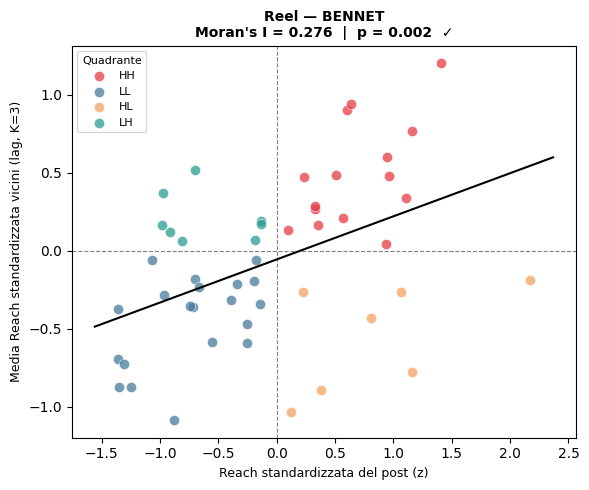

In [36]:
# MORAN INDEX REEL
# filtriamo e ordiniamo i post del top creator per i reel in ordine cronologico

# usiamo BENNET perchè è l'unico che ha un numero sufficientemente grande di reels
CREATOR = "BENNET"

# filtriamo post del creator scelto e li ordiniamo in ordine cronologico usando data e ora
data_reel = (
    reels[reels["Creator name"] == CREATOR]
    .copy()
    .assign(datetime=lambda df: pd.to_datetime(
        df["Post creation date"].astype(str) + " " + df["Post creation time"].astype(str)
    ))
    .sort_values("datetime")
    .reset_index(drop=True)
)

# chiamiamo la funzione moran
fig, ax = plt.subplots(figsize=(6, 5))
plot_moran(ax, data_reel["Reach"], f"Reel — {CREATOR}")
plt.tight_layout()
plt.show()

### INSIGHTS

BENNET obtains a Moran's I of 0.276, clearly positive and not close to zero. This means that there is a temporal correlation in its performance: reels with high Reach tend to be published close to other reels with high Reach, and the same applies for posts with low performance.
The HH quadrant (high post, high neighbors) is the most populated in the right zone of the chart, and the LL quadrant is equally compact in the left zone.

### WHAT CAN EXPLAIN IT

This pattern is consistent with the so-called hot period effect: there are temporal windows in which the creator publishes content that systematically performs better, probably due to a combination of factors. Among these, Instagram's distribution algorithm probably tends to reward creators who have achieved recent engagement, showing new content to an already "warm" audience. Also, a creator in a moment of inspiration or in a trend tends to produce more similar content in a short time, and if the format or topic works, the resulting series of posts performs homogeneously. So it's not just luck: there is a temporal logic to popularity.

### MARKETING IMPLICATIONS

A positive Moran's I suggests that it makes sense to plan campaigns or collaborations in concentrated blocks rather than distributing sponsored content randomly in the calendar. If one manages to identify when the creator is going through a hot period, for example by monitoring the last 2-3 performances, that is the best time to insert branded content. Conversely, a single isolated piece of content during a cold period has less probability of benefiting from algorithmic momentum.

## MORAN INDEX (STORIES)

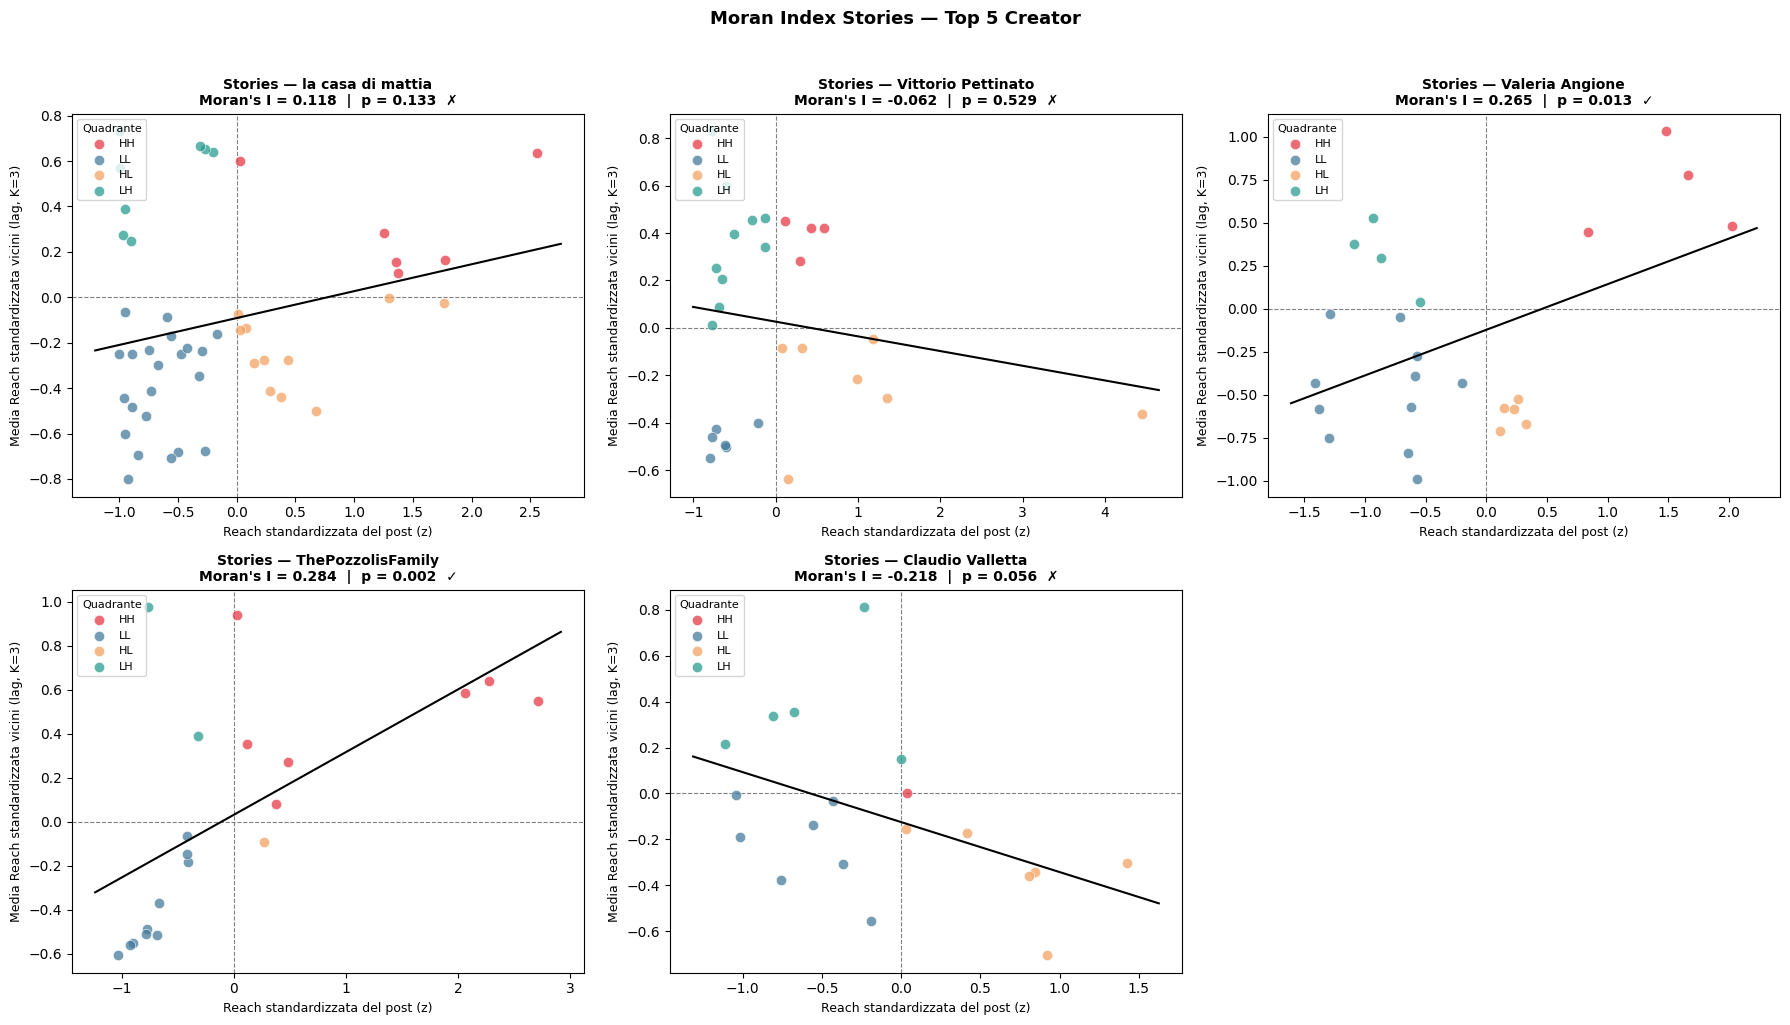

In [41]:
# MORAN INDEX STORIES

# analizziamo i top 5 creator per stories (circa minimo 25 post ciascuno)
top_five = ["la casa di mattia", "Vittorio Pettinato", "Valeria Angione",
            "ThePozzolisFamily", "Claudio Valletta"]

# grafici in griglia 2x3: prima riga i top 3, seconda riga gli altri 2 (ultima cella nascosta)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes.flatten()

# per ognuno dei top 5 creator filtriamo e ordiniamo i post usando data e ora, poi plottiamo
for idx, creator in enumerate(top_five):
    data_creator = (
        stories[stories["Creator name"] == creator]
        .copy()
        .assign(datetime=lambda df: pd.to_datetime(
            df["Post creation date"].astype(str) + " " + df["Post creation time"].astype(str)
        ))
        .sort_values("datetime")
        .reset_index(drop=True)
    )
    plot_moran(axes_flat[idx], data_creator["Reach"], f"Stories — {creator}")

# nascondiamo l'ultima cella vuota
axes_flat[-1].set_visible(False)
plt.suptitle("Moran Index Stories — Top 5 Creator", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### INSIGHTS
Three out of five creators show positive autocorrelation: la casa di mattia (I = 0.118), Valeria Angione (I = 0.265) and ThePozzolisFamily (I = 0.284). For these creators there is a local hot period effect: content published close to other well-performing content tends to perform well in turn. ThePozzolisFamily reaches the highest value among all analyzed creators.

Vittorio Pettinato (I = −0.062) remains slightly negative, but the result is probably distorted by the extreme outlier visible at z ≈ 4.5 in the chart, a single piece of content with exceptional Reach during a period of generally low performance that pulls the regression line downward. Without that outlier the signal would likely be close to zero.

Claudio Valletta (I = −0.218) is instead the clearest case of negative autocorrelation: the line has a clearly decreasing slope and the HL quadrant is well populated, with many high-Reach posts surrounded by weak neighbors. This is consistent with what emerged from the Markov Chain, where his high state was the least persistent among all creators (54.5%). For him performance peaks are episodic and do not propagate to neighboring content.

### WHAT CAN EXPLAIN IT
The fact that different creators show opposite signals suggests that the "heat streak" in stories is not a universal property of the format but an individual characteristic of the creator. This makes the Moran Index a useful tool precisely for distinguishing between creators for whom it makes sense to reason in terms of hot periods and creators for whom instead each piece of content should be treated as an independent event.

This does not contradict what emerged from the Markov Chain. The MC detects that after a piece of content above the average it is more likely to find another one above the average, and this applies to all analyzed creators. However, the Moran widens the view to 6 neighboring contents and at that point the result depends on how strong that tendency (detected by the MC) to stay above the average is. For creators like Valeria Angione or ThePozzolisFamily, where this tendency is strong, the tendency to stay above the average is maintained even widening the window and the Moran is positive. For Claudio Valletta instead the signal is weak, a high state repeats only 54.5% of the time, and at 2-3 posts distance it has already dissolved, so the Moran becomes negative. In stories the batch publication amplifies this effect: within a close sequence the Reach tends to decline from the first story onwards, and this generates many low posts surrounded by higher neighbors that further lower the index.

With the Moran Index we measured whether the tendency observed in the MCs extends to a wider neighborhood (K=3 neighbors per side) and we found that for some creators yes, for others no.

### MARKETING IMPLICATIONS
For la casa di mattia, Valeria Angione and ThePozzolisFamily the same logic as reels applies: monitor the last 2-3 stories before inserting branded content and choose a moment of recent positive performance to maximize the algorithm's momentum. For Claudio Valletta the strategy is opposite: avoid betting too much on inserting branded content right after an isolated peak, which historically does not carry subsequent content with it. For Vittorio Pettinato the signal is ambiguous and the timing choice should be made on other criteria.